# 0. Importando bibliotecas

In [270]:
pip install pandas seaborn matplotlib plotly nbformat scikit-learn statsmodels xgboost numpy --upgrade


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [271]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score


pd.set_option('display.max_columns', None)

# 1. Tratamento

In [272]:
path_df_balanco_dia ="dataset_principal/balanco_servico_dia.csv"

df_balanco_dia = pd.read_csv(path_df_balanco_dia)

df_balanco_dia.head()

,data,servico,consorcio,km_apurada,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo,versao,datetime_ultima_atualizacao,id_execucao_dbt
0,2024-02-07,SN483,Internorte,526.046,4697.59078,2572.36494,2125.22584,2125.22584,1005.89,1005.89,0.0,-1566.47494,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
1,2024-02-07,313,Internorte,2839.089,25353.06477,13883.14521,11469.91956,11469.91956,17034.77,17034.77,0.0,3151.62479,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
2,2024-02-07,385,Internorte,119.790,1069.72470,585.77310,483.95160,483.95160,998.68,998.68,0.0,412.90690,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
3,2024-02-07,920,Internorte,3377.366,30159.87838,16515.31974,13644.55864,13644.55864,24611.48,24611.48,0.0,8096.16026,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
4,2024-02-07,249,Internorte,5411.151,48321.57843,26460.52839,21861.05004,21861.05004,53311.40,53311.40,0.0,26850.87161,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e


In [273]:
df_balanco_dia_tratado = df_balanco_dia.drop(columns=['km_apurada','versao','datetime_ultima_atualizacao','id_execucao_dbt'])
df_balanco_dia_tratado.head()

,data,servico,consorcio,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-02-07,SN483,Internorte,4697.59078,2572.36494,2125.22584,2125.22584,1005.89,1005.89,0.0,-1566.47494
1,2024-02-07,313,Internorte,25353.06477,13883.14521,11469.91956,11469.91956,17034.77,17034.77,0.0,3151.62479
2,2024-02-07,385,Internorte,1069.72470,585.77310,483.95160,483.95160,998.68,998.68,0.0,412.90690
3,2024-02-07,920,Internorte,30159.87838,16515.31974,13644.55864,13644.55864,24611.48,24611.48,0.0,8096.16026
4,2024-02-07,249,Internorte,48321.57843,26460.52839,21861.05004,21861.05004,53311.40,53311.40,0.0,26850.87161


In [274]:
path_df_servico_historico = "dataset_principal/sumario_servico_dia_historico.csv"

df_servico_historico = pd.read_csv(path_df_servico_historico)

df_servico_historico.head()

,data,tipo_dia,consorcio,servico,vista,viagens,km_apurada,km_planejada,perc_km_planejada,valor_subsidio_pago,valor_penalidade,datetime_ultima_atualizacao
0,2024-04-06,Sabado,Santa Cruz,383,Realengo - Praça da República,154,5154.242,6056.38,85.10,14980.27260,0.0,2025-09-22 12:32:31.291432
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba - Campo Grande,14,438.038,377.51,116.03,1769.67352,0.0,2025-09-22 12:32:31.291432
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy - Terminal Mato Alto,72,1738.368,1786.66,97.30,7023.00672,0.0,2025-09-22 12:32:31.291432
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto - Santa Cruz,17,297.490,279.71,106.36,990.32740,0.0,2025-09-22 12:32:31.291432
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo - Terminal Campo Grande,38,265.620,231.10,114.94,1073.10480,0.0,2025-09-22 12:32:31.291432


In [275]:
df_servico_historico[['bairro_inicio', 'bairro_fim']] = df_servico_historico['vista'].str.split('-', expand=True)
df_servico_historico_tratado = df_servico_historico.drop(columns=['datetime_ultima_atualizacao','valor_subsidio_pago','vista'])


In [276]:
df_final = df_servico_historico_tratado.merge(df_balanco_dia_tratado, on=['servico', 'data','consorcio'], how='inner')

In [277]:
df_final.head()

,data,tipo_dia,consorcio,servico,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,bairro_inicio,bairro_fim,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-04-06,Sabado,Santa Cruz,383,154,5154.242,6056.38,85.10,0.0,Realengo,Praça da República,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338
1,2024-04-06,Sabado,Santa Cruz,SN898,14,438.038,377.51,116.03,0.0,Sepetiba,Campo Grande,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582
2,2024-04-06,Sabado,Santa Cruz,853,72,1738.368,1786.66,97.30,0.0,Vila Kennedy,Terminal Mato Alto,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952
3,2024-04-06,Sabado,Santa Cruz,SN885,17,297.490,279.71,106.36,0.0,Terminal Mato Alto,Santa Cruz,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610
4,2024-04-06,Sabado,Santa Cruz,845,38,265.620,231.10,114.94,0.0,Cantagalo,Terminal Campo Grande,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180


In [278]:
# Reorganizando as colunas para melhorar a leitura

col = df_final.pop('bairro_inicio')
df_final.insert(4, 'bairro_inicio', col)

col = df_final.pop('bairro_fim')
df_final.insert(5, 'bairro_fim', col)


In [279]:
df_final.head()

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-04-06,Sabado,Santa Cruz,383,Realengo,Praça da República,154,5154.242,6056.38,85.10,0.0,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba,Campo Grande,14,438.038,377.51,116.03,0.0,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy,Terminal Mato Alto,72,1738.368,1786.66,97.30,0.0,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto,Santa Cruz,17,297.490,279.71,106.36,0.0,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo,Terminal Campo Grande,38,265.620,231.10,114.94,0.0,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180


In [280]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 60143 entries, 0 to 60142
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   data                        60143 non-null  str    
 1   tipo_dia                    60143 non-null  str    
 2   consorcio                   60143 non-null  str    
 3   servico                     60143 non-null  str    
 4   bairro_inicio               60143 non-null  str    
 5   bairro_fim                  60143 non-null  str    
 6   viagens                     60143 non-null  int64  
 7   km_apurada                  60143 non-null  float64
 8   km_planejada                60143 non-null  float64
 9   perc_km_planejada           60143 non-null  float64
 10  valor_penalidade            60143 non-null  float64
 11  receita_total_esperada      59771 non-null  float64
 12  receita_tarifaria_esperada  60143 non-null  float64
 13  subsidio_esperado           59771 non-null

### 1.1 Juntar com .csv do trajetos alternativos

OBS: É importante notar que o ano do trajeto alternativos é diferente do ano do ano que estamos utilizando, apenas estamos tomando como referência o número de trajetos alternativos de um ano e supondo que eles se mantenham constantes. Porém o ideal é que possamos ter esses dados do ano correspondente.

In [281]:
path_trajetos_alt = 'dataset_principal/trajeto_alternativo_servico.csv'

df_trajetos_alt = pd.read_csv(path_trajetos_alt)

df_trajetos_alt['qtd_trajetos_alt'] = df_trajetos_alt['qtd_trajetos_alt'].astype(int)

df_trajetos_alt.head()

,servico,qtd_trajetos_alt
0,006,0
1,007,0
2,010,0
3,012,0
4,013,0


In [282]:
df_final = df_final.merge(df_trajetos_alt, on=['servico'], how='inner')

df_final.head()

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo,qtd_trajetos_alt
0,2024-04-06,Sabado,Santa Cruz,383,Realengo,Praça da República,154,5154.242,6056.38,85.10,0.0,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338,0
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba,Campo Grande,14,438.038,377.51,116.03,0.0,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582,4
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy,Terminal Mato Alto,72,1738.368,1786.66,97.30,0.0,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952,0
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto,Santa Cruz,17,297.490,279.71,106.36,0.0,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610,2
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo,Terminal Campo Grande,38,265.620,231.10,114.94,0.0,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180,0


### 1.2 Tratamento de nulos

In [283]:
df_final[df_final.isnull().any(axis=1)]

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo,qtd_trajetos_alt
40777,2024-08-16,Dia Útil,Intersul,110,Terminal Gentileza,Jardim de Alah,210,3194.988,3679.61,86.83,0.0,NaN,15623.49132,NaN,NaN,NaN,22038.14,NaN,6414.64868,0
40778,2024-08-16,Dia Útil,Intersul,448,Furnas,São Conrado,34,437.954,463.72,94.44,0.0,NaN,2141.59506,NaN,NaN,NaN,1822.13,NaN,-319.46506,0
40779,2024-08-16,Dia Útil,Intersul,LECD96,Metrô Botafogo,Terminal Alvorada,262,6064.908,5833.80,103.96,0.0,NaN,29657.40012,NaN,NaN,NaN,45948.76,NaN,16291.35988,0
40780,2024-08-16,Dia Útil,Intersul,472,Triagem,Leme,138,3002.880,2828.80,106.15,0.0,NaN,14575.33938,NaN,NaN,NaN,15744.03,NaN,1168.69062,4
40781,2024-08-16,Dia Útil,Intersul,461,São Cristóvão,Ipanema,116,3080.032,3425.21,89.92,0.0,NaN,15061.35648,NaN,NaN,NaN,17873.47,NaN,2812.11352,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41144,2024-08-16,Dia Útil,Santa Cruz,866,Terminal Campo Grande,Pedra de Guaratiba,56,2274.832,2274.83,100.00,0.0,NaN,11123.92848,NaN,NaN,NaN,10969.30,NaN,-154.62848,2
41145,2024-08-16,Dia Útil,Transcarioca,SN954,Terminal Taquara,Recreio dos Bandeirantes,9,194.127,173.08,112.16,0.0,NaN,949.28103,NaN,NaN,NaN,223.24,NaN,-726.04103,0
41146,2024-08-16,Dia Útil,Transcarioca,954,Terminal Taquara,Recreio dos Bandeirantes,209,4522.402,4413.64,102.46,0.0,NaN,21902.95059,NaN,NaN,NaN,32149.72,NaN,10246.76941,0
41147,2024-08-16,Dia Útil,Santa Cruz,SV866,Terminal Campo Grande,Terminal Pingo d'Água,63,1198.309,1216.67,98.49,0.0,NaN,5859.73101,NaN,NaN,NaN,6660.95,NaN,801.21899,0


In [284]:
df_final = df_final.dropna().reset_index(drop=True)

In [285]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 59771 entries, 0 to 59770
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   data                        59771 non-null  str    
 1   tipo_dia                    59771 non-null  str    
 2   consorcio                   59771 non-null  str    
 3   servico                     59771 non-null  str    
 4   bairro_inicio               59771 non-null  str    
 5   bairro_fim                  59771 non-null  str    
 6   viagens                     59771 non-null  int64  
 7   km_apurada                  59771 non-null  float64
 8   km_planejada                59771 non-null  float64
 9   perc_km_planejada           59771 non-null  float64
 10  valor_penalidade            59771 non-null  float64
 11  receita_total_esperada      59771 non-null  float64
 12  receita_tarifaria_esperada  59771 non-null  float64
 13  subsidio_esperado           59771 non-null

# 2. Juntar com .csv externo de dados de chuva

In [286]:
df_chuva_externo = pd.read_csv('dados_pluviometricos_extraidos/Chuva_24h.csv')
df_chuva_externo.head(100)

,data,24 h,Bairro
0,2023-12-31,1.2,ALTO DA BOA VISTA
1,2024-01-01,0.0,ALTO DA BOA VISTA
2,2024-01-02,0.0,ALTO DA BOA VISTA
3,2024-01-03,20.8,ALTO DA BOA VISTA
4,2024-01-04,11.4,ALTO DA BOA VISTA
...,...,...,...
95,2024-04-04,0.0,ALTO DA BOA VISTA
96,2024-04-05,0.0,ALTO DA BOA VISTA
97,2024-04-06,0.0,ALTO DA BOA VISTA
98,2024-04-07,0.0,ALTO DA BOA VISTA


In [287]:
# Garantindo que os dois estão no formato de data do pandas
df_final['data'] = pd.to_datetime(df_final['data'])
df_chuva_externo['data'] = pd.to_datetime(df_chuva_externo['data'])

In [288]:
# Padronização de variáveis e colunas
df_chuva_externo = df_chuva_externo.rename(columns={
    '24 h': 'chuva_mm_24h'
})

df_final['bairro_inicio'] = df_final['bairro_inicio'].astype(str).str.strip().str.upper()
df_final['bairro_fim'] = df_final['bairro_fim'].astype(str).str.strip().str.upper()

In [289]:
# Junção dos dataframe bairro início

df_chuva_inicio = df_chuva_externo.rename(columns={
    'Bairro': 'bairro_inicio',
    'chuva_mm_24h': 'chuva_inicio'
})

df_chuva = df_final.merge(
    df_chuva_inicio[['data', 'bairro_inicio', 'chuva_inicio']],
    on=['data', 'bairro_inicio'],
    how='inner'
)

In [290]:
df_chuva.info()

<class 'pandas.DataFrame'>
RangeIndex: 11015 entries, 0 to 11014
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   data                        11015 non-null  datetime64[us]
 1   tipo_dia                    11015 non-null  str           
 2   consorcio                   11015 non-null  str           
 3   servico                     11015 non-null  str           
 4   bairro_inicio               11015 non-null  str           
 5   bairro_fim                  11015 non-null  str           
 6   viagens                     11015 non-null  int64         
 7   km_apurada                  11015 non-null  float64       
 8   km_planejada                11015 non-null  float64       
 9   perc_km_planejada           11015 non-null  float64       
 10  valor_penalidade            11015 non-null  float64       
 11  receita_total_esperada      11015 non-null  float64       
 12  r

In [291]:
# Junção dos dataframe bairro fim

df_chuva_fim = df_chuva_externo.rename(columns={
    'Bairro': 'bairro_fim',
    'chuva_mm_24h': 'chuva_fim'
})

df_chuva = df_chuva.merge(
    df_chuva_fim[['data', 'bairro_fim', 'chuva_fim']],
    on=['data', 'bairro_fim'],
    how='inner'
)

In [292]:
df_chuva['chuva_media'] = (
    df_chuva['chuva_inicio'] +
    df_chuva['chuva_fim']
) / 2

In [293]:
df_chuva.head()

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo,qtd_trajetos_alt,chuva_inicio,chuva_fim,chuva_media
0,2024-04-06,Sabado,Santa Cruz,SN898,SEPETIBA,CAMPO GRANDE,14,438.038,377.51,116.03,0.0,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582,4,0.0,0.0,0.0
1,2024-06-20,Dia Útil,Intersul,519,URCA,COPACABANA,35,502.915,546.02,92.11,0.0,4491.03095,2459.25435,2031.77660,0.00000,5525.74660,3493.97,2031.77660,1034.71565,2,0.0,0.0,0.0
2,2024-06-20,Dia Útil,Santa Cruz,898,SEPETIBA,CAMPO GRANDE,80,2519.237,2957.29,85.19,0.0,22496.78641,12319.06893,10177.71748,152.26882,17904.33866,7878.89,10025.44866,-4440.17893,4,0.0,0.0,0.0
3,2024-06-20,Dia Útil,Santa Cruz,870,SEPETIBA,SANTA CRUZ,67,943.209,1014.23,93.00,0.0,8422.85637,4612.29201,3810.56436,1113.57444,6541.46992,3844.48,2696.98992,-767.81201,4,0.0,0.0,0.0
4,2024-06-20,Dia Útil,Transcarioca,558,CIDADE DE DEUS,COPACABANA,13,480.568,445.52,107.87,0.0,4291.47224,2349.97752,1941.49472,539.07678,3272.27794,1869.86,1402.41794,-480.11752,17,0.0,0.0,0.0


In [294]:
df_chuva.info()

<class 'pandas.DataFrame'>
RangeIndex: 917 entries, 0 to 916
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   data                        917 non-null    datetime64[us]
 1   tipo_dia                    917 non-null    str           
 2   consorcio                   917 non-null    str           
 3   servico                     917 non-null    str           
 4   bairro_inicio               917 non-null    str           
 5   bairro_fim                  917 non-null    str           
 6   viagens                     917 non-null    int64         
 7   km_apurada                  917 non-null    float64       
 8   km_planejada                917 non-null    float64       
 9   perc_km_planejada           917 non-null    float64       
 10  valor_penalidade            917 non-null    float64       
 11  receita_total_esperada      917 non-null    float64       
 12  recei

# 3. Análise gráfica dos dados gerais

In [295]:
# Calcula o total do saldo por serviço
total_balanco = df_final.groupby('servico')['saldo'].sum()

# Pega os índices dos 5 maiores serviços lucrativos
top5 = total_balanco.nlargest(5).index

# Pega os índices dos 5 maiores serviços que dão prejuízo 
worst5 = total_balanco.nsmallest(5).index

# Cria uma lista com os 5 mais lucrativos e 5 desvantajosos
selecionar_servicos = list(top5) + list(worst5)

# Filtra o dataset apenas para mostrar esses serviços
df_final_melhores_piores = df_final[df_final['servico'].isin(selecionar_servicos)].groupby('servico', as_index = False)['saldo'].mean()

# Ordenando
df_final_melhores_piores = df_final_melhores_piores.sort_values(by='saldo', ascending=False)

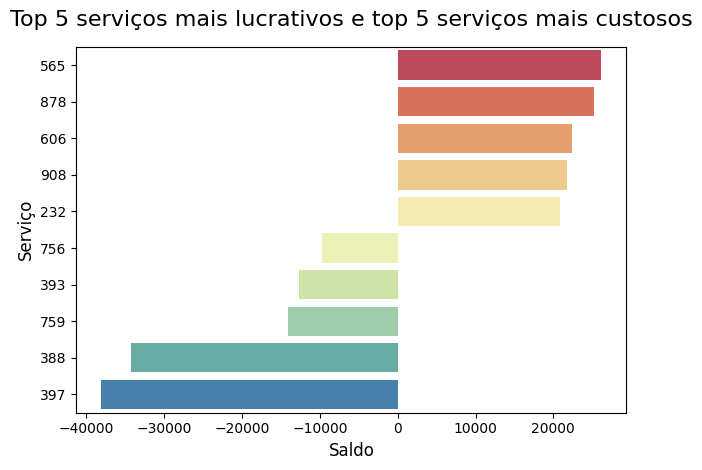

In [296]:
ax = sns.barplot(
    data=df_final_melhores_piores,
    x="saldo",
    y="servico",
    palette = 'Spectral',
    hue="servico"
)

plt.title("Top 5 serviços mais lucrativos e top 5 serviços mais custosos", fontsize=16, pad=15)
plt.xlabel("Saldo", fontsize=12)
plt.ylabel("Serviço", fontsize=12)

plt.tight_layout()
plt.show()

In [297]:
# Calcula o total do saldo por serviço
df_final_maiores_subsidios_glosados = df_final.groupby('servico')['subsidio_glosado'].sum()

# Pega os 5 maiores serviços
top20 = df_final_maiores_subsidios_glosados.nlargest(20).index

# Converte para lista
selecionar_servicos = list(top20)

# Filtra o dataset apenas para mostrar esses serviços
df_final_maiores_subsidios_glosados =  df_final[df_final['servico'].isin(selecionar_servicos)].groupby('servico', as_index=False)['subsidio_glosado'].sum()

# Colocar em ordem decrescente
df_final_maiores_subsidios_glosados= df_final_maiores_subsidios_glosados.sort_values(by='subsidio_glosado', ascending = False)


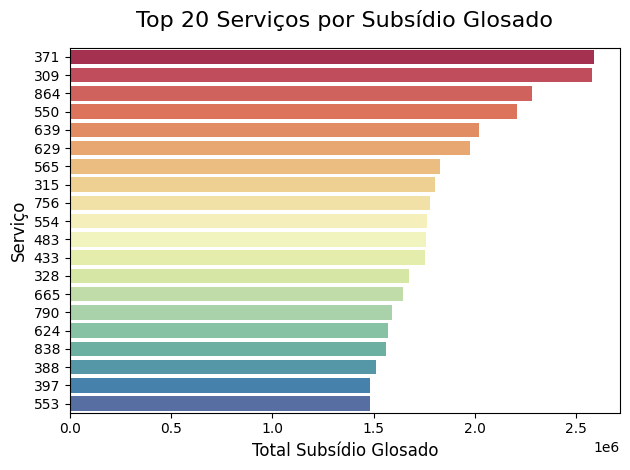

In [298]:
ax = sns.barplot(
    data=df_final_maiores_subsidios_glosados,
    x="subsidio_glosado",
    y="servico",
    palette = 'Spectral',
    hue="servico"
)

plt.title("Top 20 Serviços por Subsídio Glosado", fontsize=16, pad=15)
plt.xlabel("Total Subsídio Glosado", fontsize=12)
plt.ylabel("Serviço", fontsize=12)

plt.tight_layout()
plt.show()

In [299]:
print(df_final['servico'].nunique())

438


### 3.1 Verificar se linhas fantasmas foram contabilizadas nos dados

fonte: https://extra.globo.com/noticias/rio/moradores-sofrem-com-onibus-fantasmas-na-zona-oeste-rv1-1-23836888.html

In [300]:
linhas_fantasmas_2019 = ['358','365','366','388','395','398','364','389','739','744','751','767','874','933']

for servico in linhas_fantasmas_2019:
    if(servico in df_final['servico'].values):
        print(servico)

388
395
389


Curiosidade: Dado que o serviço 388 é listado no gráfico de maiores subsídios glosados, ou seja, ele é um dos top 20 dentre 438 serviços, e há relatos de 2019 que esse serviço operava como linha fantasma, é bem provável que essa linha não tenha melhorado até o período de 2024-2025, e possívelmente até hoje, atuando como um serviço fraudulento para tentativa de captar subsídios.

### 3.2 Verificar a lucratividade por dia da semana

In [301]:
# Calcula o total do saldo por serviço
df_dia_balanco = df_final.groupby('tipo_dia', as_index= False)['saldo'].mean()

# Ordenando
df_dia_balanco = df_dia_balanco.sort_values(by='saldo', ascending=False)

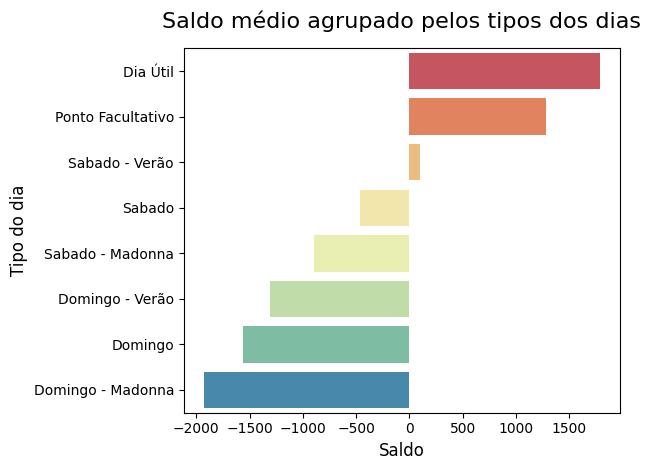

In [302]:
ax = sns.barplot(
    data=df_dia_balanco,
    x="saldo",
    y="tipo_dia",
    palette = 'Spectral',
    hue="tipo_dia"
)

plt.title("Saldo médio agrupado pelos tipos dos dias", fontsize=16, pad=15)
plt.xlabel("Saldo", fontsize=12)
plt.ylabel("Tipo do dia", fontsize=12)

plt.tight_layout()
plt.show()

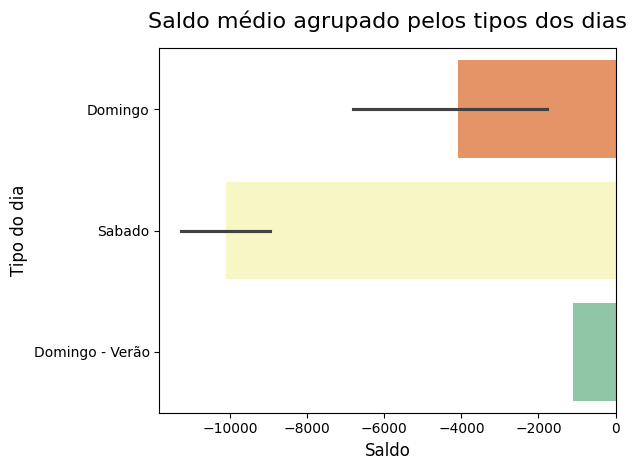

In [303]:

ax = sns.barplot(
    data=df_final.nlargest(10, 'perc_km_planejada'),
    x="saldo",
    y="tipo_dia",
    palette = 'Spectral',
    hue="tipo_dia"
)

plt.title("Saldo médio agrupado pelos tipos dos dias", fontsize=16, pad=15)
plt.xlabel("Saldo", fontsize=12)
plt.ylabel("Tipo do dia", fontsize=12)

plt.tight_layout()
plt.show()

# 4. Pré-processamento

In [304]:
df_ml = df_final
df_ml.head()

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo,qtd_trajetos_alt
0,2024-04-06,Sabado,Santa Cruz,383,REALENGO,PRAÇA DA REPÚBLICA,154,5154.242,6056.38,85.10,0.0,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338,0
1,2024-04-06,Sabado,Santa Cruz,SN898,SEPETIBA,CAMPO GRANDE,14,438.038,377.51,116.03,0.0,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582,4
2,2024-04-06,Sabado,Santa Cruz,853,VILA KENNEDY,TERMINAL MATO ALTO,72,1738.368,1786.66,97.30,0.0,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952,0
3,2024-04-06,Sabado,Santa Cruz,SN885,TERMINAL MATO ALTO,SANTA CRUZ,17,297.490,279.71,106.36,0.0,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610,2
4,2024-04-06,Sabado,Santa Cruz,845,CANTAGALO,TERMINAL CAMPO GRANDE,38,265.620,231.10,114.94,0.0,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180,0


In [305]:
# Seleção inicial de features (Remoção de variáveis que não fazem sentido para o treinamento)

df_ml = df_ml[['tipo_dia','bairro_inicio','bairro_fim','viagens','km_apurada','km_planejada','perc_km_planejada','qtd_trajetos_alt','saldo','subsidio_esperado']]

df_ml.head()

,tipo_dia,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,qtd_trajetos_alt,saldo,subsidio_esperado
0,Sabado,REALENGO,PRAÇA DA REPÚBLICA,154,5154.242,6056.38,85.10,0,-863.48338,20823.13768
1,Sabado,SEPETIBA,CAMPO GRANDE,14,438.038,377.51,116.03,4,-1578.70582,1769.67352
2,Sabado,VILA KENNEDY,TERMINAL MATO ALTO,72,1738.368,1786.66,97.30,0,-1654.61952,7023.00672
3,Sabado,TERMINAL MATO ALTO,SANTA CRUZ,17,297.490,279.71,106.36,2,-1074.60610,1201.85960
4,Sabado,CANTAGALO,TERMINAL CAMPO GRANDE,38,265.620,231.10,114.94,0,-883.83180,1073.10480


### 4.1 One-hot-encoding

Código para transformar variáveis categóricas em numéricas utilizando o one-hot-encoding. No caso do bairro, como são muitos, a matrix ficaria muito esparsa, então foi feito um tratamento adicional para transformar os bairros para regiões.

In [306]:
# Transformando variáveis categóricas em numéricas
encoder = OneHotEncoder(sparse_output=False)

encoded_array = encoder.fit_transform(df_ml[['tipo_dia']])


encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['tipo_dia']),
    index = df_ml.index
)

# Junta as novas colunas ao dataframe original
df_ml = pd.concat([df_ml, encoded_df], axis=1)

# Remove a coluna original (já que agora temos as versões encodadas)
df_ml = df_ml.drop('tipo_dia', axis=1)

df_ml.head()


,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,qtd_trajetos_alt,saldo,subsidio_esperado,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão
0,REALENGO,PRAÇA DA REPÚBLICA,154,5154.242,6056.38,85.10,0,-863.48338,20823.13768,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,SEPETIBA,CAMPO GRANDE,14,438.038,377.51,116.03,4,-1578.70582,1769.67352,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,VILA KENNEDY,TERMINAL MATO ALTO,72,1738.368,1786.66,97.30,0,-1654.61952,7023.00672,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,TERMINAL MATO ALTO,SANTA CRUZ,17,297.490,279.71,106.36,2,-1074.60610,1201.85960,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,CANTAGALO,TERMINAL CAMPO GRANDE,38,265.620,231.10,114.94,0,-883.83180,1073.10480,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [307]:
# Dicionário de bairros para zonas no RJ, foi utilizado IA para fazer esses dicionários
zonas_rj = {
    'ZONA SUL': [
        # Bairros Oficiais e Sub-bairros/Terminais
        'COPACABANA', 'IPANEMA', 'LEBLON', 'BOTAFOGO', 'FLAMENGO', 'GÁVEA', 'GAVEA', 
        'URCA', 'LEME', 'CATETE', 'GLÓRIA', 'GLORIA', 'LARANJEIRAS', 'COSME VELHO', 
        'SÃO CONRADO', 'SAO CONRADO', 'ROCINHA', 'VIDIGAL', 'HUMAITÁ', 'JARDIM BOTÂNICO',
        'CANTAGALO', 'JARDIM DE ALAH', 'LARGO DO MACHADO', 'SILVESTRE', 'GENERAL OSÓRIO'
    ],
    'ZONA OESTE': [
        # Bairros Oficiais
        'BARRA DA TIJUCA', 'RECREIO', 'JACAREPAGUÁ', 'JACAREPAGUA', 'CAMPO GRANDE', 
        'BANGU', 'SANTA CRUZ', 'TAQUARA', 'FREGUESIA', 'ANIL', 'CIDADE DE DEUS', 
        'CURICICA', 'PECHINCHA', 'PRAÇA SECA', 'VILA VALQUEIRE', 'GUARATIBA', 'SEPETIBA', 
        'PACIÊNCIA', 'REALENGO', 'PADRE MIGUEL', 'MAGALHÃES BASTOS', 'SULACAP', 'VILA KENNEDY',
        'VARGEM GRANDE', 'VARGEM PEQUENA', 'ITANHANGÁ', 'JOÁ', 'PAU DA FOME', 'COVANCA',
        'TANQUE', 'CAMORIM', 'SANTÍSSIMO', 'SENADOR CAMARÁ', 
        # Sub-bairros, Comunidades e Localidades
        'RIO DA PRATA', 'MENDANHA', 'CABOCLOS', 'URUCÂNIA', 'CATIRI', 'CAROBINHA', 'PIABAS',
        'RIO DAS PEDRAS', 'GARDÊNIA AZUL', 'COLÔNIA', 'BOA ESPERANÇA', 'CESARÃO', 
        'CONJUNTO MANGUARIBA', 'CONJUNTO DOS PALMARES', 'COQUEIROS', 'JABOUR', 'JARDIM PALMARES',
        'JARDIM VIOLETA', 'JESUÍTAS', 'LARGO DO AARÃO', 'LARGO DO CORREIA', 'PEDREGOSO',
        'SAGRADO CORAÇÃO', 'SALIM', 'SÃO BENEDITO', 'SÃO FERNANDO', 'VILA ALIANÇA', 'TIJUQUINHA',
        'TRÊS RIOS', 'BARRA SUL', 'CABUÇU DE BAIXO', 'CAPOEIRA GRANDE', 'SANTA MARGARIDA', 'SANTA MARIA',
        # Terminais e Estações
        "PINGO D'ÁGUA", "PINGO D'AGUA", 'TERMINAL MATO ALTO', 'TERMINAL ALVORADA', 
        'JARDIM OCEÂNICO', 'TERMINAL DEODORO', 'MERCK', 'TERMINAL MAGARÇA'
    ],
    'ZONA NORTE': [
        # Bairros Oficiais
        'TIJUCA', 'MÉIER', 'MEIER', 'MADUREIRA', 'PENHA', 'PAVUNA', 'BONSUCESSO', 'OLARIA', 
        'RAMOS', 'IRAJÁ', 'IRAJA', 'VILA DA PENHA', 'VICENTE DE CARVALHO', 'CASCADURA', 
        'QUINTINO', 'PIEDADE', 'ENGENHO DE DENTRO', 'ENGENHO NOVO', 'LINS DE VASCONCELOS', 
        'CACHAMBI', 'DEL CASTILHO', 'INHAÚMA', 'INHAUMA', 'TOMÁS COELHO', 'TOMAS COELHO', 
        'SÃO CRISTÓVÃO', 'SAO CRISTOVAO', 'MARACANÃ', 'MARACANA', 'VILA ISABEL', 'GRAJAÚ', 
        'GRAJAU', 'ANDARAÍ', 'ANDARAI', 'BENTO RIBEIRO', 'MARECHAL HERMES', 'ROCHA MIRANDA',
        'HONÓRIO GURGEL', 'HONORIO GURGEL', 'ACARI', 'CORDOVIL', 'PARADA DE LUCAS', 'TRIAGEM', 
        'MUDA', 'JARDIM AMÉRICA', 'ANCHIETA', 'BANANAL', 'BANCÁRIOS', 'RIBEIRA', 'TUBIACANGA',
        'ENGENHEIRO LEAL', 'ENGENHO DA RAINHA', 'ÁGUA SANTA', 'ABOLIÇÃO', 'JACARÉ',
        # Sub-bairros, Comunidades e Localidades
        'FIOCRUZ', 'FUNDÃO', 'GROTÃO', 'MARIÓPOLIS', 'PARQUE UNIÃO', 'VILA CRUZEIRO', 'MARÉ',
        'SAENS PEÑA', 'USINA', 'SERRINHA', 'VILA DO JOÃO', 'NORTE SHOPPING', 
        'AEROPORTO INTERNACIONAL DO RJ', 'BAIRRO MONTE SANTO', 'SANTA ALEXANDRINA', 'SÃO JANUÁRIO'
    ],
    'CENTRO': [
        # Bairros e Sub-bairros
        'CENTRO', 'LAPA', 'SAÚDE', 'SAUDE', 'GAMBOA', 'SANTO CRISTO', 'RIO COMPRIDO', 
        'CATUMBI', 'ESTÁCIO', 'ESTACIO', 'CIDADE NOVA', 'PASSEIO', 'CENTRAL', 'CAJU', 
        'BAIRRO DE FÁTIMA', 'CANDELÁRIA', 'PAULA MATOS', 'RODOVIÁRIA', 
        # Terminais
        'TERMINAL GENTILEZA'
    ]
}

In [308]:
# Inverte o dicionário para facilitar a busca { 'COPACABANA': 'ZONA SUL', ... }
bairro_para_zona = {}
for zona, bairros in zonas_rj.items():
    for bairro in bairros:
        bairro_para_zona[bairro] = zona

# Função para classificar considerando correspondência parcial (substrings)
def classificar_zona(nome_bairro):
    if pd.isna(nome_bairro) or nome_bairro == 'NAN':
        return 'NÃO INFORMADO'
    
    # Tenta a busca direta primeiro
    if nome_bairro in bairro_para_zona:
        return bairro_para_zona[nome_bairro]
    
    # Tenta a busca por substring (captura casos como "TERMINAL TAQUARA", "ALTO GÁVEA", etc.)
    for bairro_chave, zona in bairro_para_zona.items():
        if bairro_chave in nome_bairro:
            return zona
            
    # Retorna OUTROS se o bairro não estiver no dicionário
    return 'OUTROS'

# Aplica a função para criar as novas colunas
df_ml['zona_inicio'] = df_ml['bairro_inicio'].apply(classificar_zona)
df_ml['zona_fim'] = df_ml['bairro_fim'].apply(classificar_zona)

In [309]:
bairros_nao_mapeados = df_ml[df_ml['zona_inicio'] == 'OUTROS']['bairro_inicio'].unique()
print("\nBairros não mapeados (Início):", bairros_nao_mapeados)


Bairros não mapeados (Início): <StringArray>
['FURNAS']
Length: 1, dtype: str


In [310]:
# Reorganizando as colunas para melhorar a leitura

df_ml = df_ml.drop(['bairro_inicio','bairro_fim'],axis=1)

col = df_ml.pop('zona_inicio')
df_ml.insert(4, 'zona_inicio', col)

col = df_ml.pop('zona_fim')
df_ml.insert(5, 'zona_fim', col)

In [311]:
df_ml.head(10)

,viagens,km_apurada,km_planejada,perc_km_planejada,zona_inicio,zona_fim,qtd_trajetos_alt,saldo,subsidio_esperado,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão
0,154,5154.242,6056.38,85.10,ZONA OESTE,OUTROS,0,-863.48338,20823.13768,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,14,438.038,377.51,116.03,ZONA OESTE,ZONA OESTE,4,-1578.70582,1769.67352,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,72,1738.368,1786.66,97.30,ZONA OESTE,ZONA OESTE,0,-1654.61952,7023.00672,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,17,297.490,279.71,106.36,ZONA OESTE,ZONA OESTE,2,-1074.60610,1201.85960,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,38,265.620,231.10,114.94,ZONA SUL,ZONA OESTE,0,-883.83180,1073.10480,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,163,4127.956,3348.08,123.29,ZONA OESTE,ZONA OESTE,0,1572.29516,16676.94224,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,46,839.978,982.61,85.48,ZONA OESTE,ZONA OESTE,0,-1835.80242,3393.51112,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,74,525.363,596.36,88.09,ZONA OESTE,ZONA OESTE,0,1598.10493,2122.46652,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,57,1975.352,2132.02,92.65,ZONA OESTE,ZONA NORTE,81,-2242.01128,7980.42208,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,42,563.598,630.69,89.36,ZONA OESTE,OUTROS,0,-1465.56422,2276.93592,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [312]:
# Transformando variáveis categóricas em numéricas

encoded_array = encoder.fit_transform(df_ml[['zona_inicio']])

encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['zona_inicio'])
)

# Junta as novas colunas ao dataframe original
df_ml = pd.concat([df_ml, encoded_df], axis=1)

# Remove a coluna original (já que agora temos as versões encodadas)
df_ml = df_ml.drop('zona_inicio', axis=1)

In [313]:
# Transformando variáveis categóricas em numéricas
encoded_array = encoder.fit_transform(df_ml[['zona_fim']])

encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['zona_fim'])
)

# Junta as novas colunas ao dataframe original
df_ml = pd.concat([df_ml, encoded_df], axis=1)

# Remove a coluna original (já que agora temos as versões encodadas)
df_ml = df_ml.drop('zona_fim', axis=1)

In [314]:
df_ml.head()

,viagens,km_apurada,km_planejada,perc_km_planejada,qtd_trajetos_alt,saldo,subsidio_esperado,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão,zona_inicio_CENTRO,zona_inicio_OUTROS,zona_inicio_ZONA NORTE,zona_inicio_ZONA OESTE,zona_inicio_ZONA SUL,zona_fim_CENTRO,zona_fim_OUTROS,zona_fim_ZONA NORTE,zona_fim_ZONA OESTE,zona_fim_ZONA SUL
0,154,5154.242,6056.38,85.10,0,-863.48338,20823.13768,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,14,438.038,377.51,116.03,4,-1578.70582,1769.67352,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,72,1738.368,1786.66,97.30,0,-1654.61952,7023.00672,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,17,297.490,279.71,106.36,2,-1074.60610,1201.85960,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,38,265.620,231.10,114.94,0,-883.83180,1073.10480,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [315]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 59771 entries, 0 to 59770
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   viagens                     59771 non-null  int64  
 1   km_apurada                  59771 non-null  float64
 2   km_planejada                59771 non-null  float64
 3   perc_km_planejada           59771 non-null  float64
 4   qtd_trajetos_alt            59771 non-null  int64  
 5   saldo                       59771 non-null  float64
 6   subsidio_esperado           59771 non-null  float64
 7   tipo_dia_Dia Útil           59771 non-null  float64
 8   tipo_dia_Domingo            59771 non-null  float64
 9   tipo_dia_Domingo - Madonna  59771 non-null  float64
 10  tipo_dia_Domingo - Verão    59771 non-null  float64
 11  tipo_dia_Ponto Facultativo  59771 non-null  float64
 12  tipo_dia_Sabado             59771 non-null  float64
 13  tipo_dia_Sabado - Madonna   59771 non-null

### 4.2 Normalização de valores

In [316]:
scaler = StandardScaler()

df_ml[['km_apurada','km_planejada','perc_km_planejada','qtd_trajetos_alt','saldo','viagens','subsidio_esperado']] = scaler.fit_transform(
    df_ml[['km_apurada','km_planejada','perc_km_planejada','qtd_trajetos_alt','saldo','viagens','subsidio_esperado']]
)

df_ml.head()

,viagens,km_apurada,km_planejada,perc_km_planejada,qtd_trajetos_alt,saldo,subsidio_esperado,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão,zona_inicio_CENTRO,zona_inicio_OUTROS,zona_inicio_ZONA NORTE,zona_inicio_ZONA OESTE,zona_inicio_ZONA SUL,zona_fim_CENTRO,zona_fim_OUTROS,zona_fim_ZONA NORTE,zona_fim_ZONA OESTE,zona_fim_ZONA SUL
0,0.395539,1.090283,1.305882,-0.719801,-0.338902,-0.280484,1.013618,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.837583,-0.770351,-0.795898,0.929185,-0.122716,-0.384932,-0.761261,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.326718,-0.257346,-0.274364,-0.069377,-0.338902,-0.396018,-0.271900,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.811159,-0.825800,-0.832094,0.413643,-0.230809,-0.311316,-0.814155,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.626190,-0.838373,-0.850085,0.871073,-0.338902,-0.283456,-0.826149,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### 4.3 Tratamento dos dados de chuva

In [317]:
df_chuva = df_chuva[['tipo_dia','bairro_inicio','bairro_fim','viagens','km_apurada','km_planejada','perc_km_planejada','qtd_trajetos_alt','saldo','subsidio_esperado','chuva_media']]
df_chuva['zona_inicio'] = df_chuva['bairro_inicio'].apply(classificar_zona)
df_chuva['zona_fim'] = df_chuva['bairro_fim'].apply(classificar_zona)

df_chuva = df_chuva.drop(['bairro_inicio','bairro_fim'],axis=1)

col = df_chuva.pop('zona_inicio')
df_chuva.insert(4, 'zona_inicio', col)

col = df_chuva.pop('zona_fim')
df_chuva.insert(5, 'zona_fim', col)

df_chuva.head()

,tipo_dia,viagens,km_apurada,km_planejada,zona_inicio,zona_fim,perc_km_planejada,qtd_trajetos_alt,saldo,subsidio_esperado,chuva_media
0,Sabado,14,438.038,377.51,ZONA OESTE,ZONA OESTE,116.03,4,-1578.70582,1769.67352,0.0
1,Dia Útil,35,502.915,546.02,ZONA SUL,ZONA SUL,92.11,2,1034.71565,2031.77660,0.0
2,Dia Útil,80,2519.237,2957.29,ZONA OESTE,ZONA OESTE,85.19,4,-4440.17893,10177.71748,0.0
3,Dia Útil,67,943.209,1014.23,ZONA OESTE,ZONA OESTE,93.00,4,-767.81201,3810.56436,0.0
4,Dia Útil,13,480.568,445.52,ZONA OESTE,ZONA SUL,107.87,17,-480.11752,1941.49472,0.0


In [318]:
encoded_array = encoder.fit_transform(df_chuva[['tipo_dia']])

encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['tipo_dia']),
    index = df_chuva.index
)

df_chuva = pd.concat([df_chuva,encoded_df], axis=1)

df_chuva = df_chuva.drop('tipo_dia', axis=1)

df_chuva.head()


,viagens,km_apurada,km_planejada,zona_inicio,zona_fim,perc_km_planejada,qtd_trajetos_alt,saldo,subsidio_esperado,chuva_media,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão
0,14,438.038,377.51,ZONA OESTE,ZONA OESTE,116.03,4,-1578.70582,1769.67352,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,35,502.915,546.02,ZONA SUL,ZONA SUL,92.11,2,1034.71565,2031.77660,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,80,2519.237,2957.29,ZONA OESTE,ZONA OESTE,85.19,4,-4440.17893,10177.71748,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,67,943.209,1014.23,ZONA OESTE,ZONA OESTE,93.00,4,-767.81201,3810.56436,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13,480.568,445.52,ZONA OESTE,ZONA SUL,107.87,17,-480.11752,1941.49472,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [319]:
encoded_array = encoder.fit_transform(df_chuva[['zona_inicio']])

encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['zona_inicio'])
)

# Junta as novas colunas ao dataframe original
df_chuva = pd.concat([df_chuva, encoded_df], axis=1)

# Remove a coluna original (já que agora temos as versões encodadas)
df_chuva = df_chuva.drop('zona_inicio', axis=1)


# Transformando variáveis categóricas em numéricas
encoded_array = encoder.fit_transform(df_chuva[['zona_fim']])

encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['zona_fim'])
)

# Junta as novas colunas ao dataframe original
df_chuva = pd.concat([df_chuva, encoded_df], axis=1)

# Remove a coluna original (já que agora temos as versões encodadas)
df_chuva = df_chuva.drop('zona_fim', axis=1)

df_chuva.head()

,viagens,km_apurada,km_planejada,perc_km_planejada,qtd_trajetos_alt,saldo,subsidio_esperado,chuva_media,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão,zona_inicio_ZONA OESTE,zona_inicio_ZONA SUL,zona_fim_ZONA OESTE,zona_fim_ZONA SUL
0,14,438.038,377.51,116.03,4,-1578.70582,1769.67352,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,35,502.915,546.02,92.11,2,1034.71565,2031.77660,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,80,2519.237,2957.29,85.19,4,-4440.17893,10177.71748,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,67,943.209,1014.23,93.00,4,-767.81201,3810.56436,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,13,480.568,445.52,107.87,17,-480.11752,1941.49472,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [320]:
scaler = StandardScaler()

df_chuva[['km_apurada','km_planejada','perc_km_planejada','qtd_trajetos_alt','saldo','viagens','subsidio_esperado','chuva_media']] = scaler.fit_transform(
    df_chuva[['km_apurada','km_planejada','perc_km_planejada','qtd_trajetos_alt','saldo','viagens','subsidio_esperado','chuva_media']]
)

df_chuva.head()

,viagens,km_apurada,km_planejada,perc_km_planejada,qtd_trajetos_alt,saldo,subsidio_esperado,chuva_media,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão,zona_inicio_ZONA OESTE,zona_inicio_ZONA SUL,zona_fim_ZONA OESTE,zona_fim_ZONA SUL
0,-1.018227,-0.677075,-0.718381,1.151148,-0.167256,-0.410670,-0.675208,-0.302781,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.085845,-0.573877,-0.482030,-0.713989,-0.566666,0.891661,-0.572019,-0.302781,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,1.912117,2.633422,2.899999,-1.253568,-0.167256,-1.836610,2.635008,-0.302781,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.334928,0.126484,0.174678,-0.644592,-0.167256,-0.006582,0.128283,-0.302781,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.062626,-0.609424,-0.622990,0.514881,2.428909,0.136783,-0.607563,-0.302781,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


# 5. Analisando correlação entre as features

### 5.1 Sem chuva

In [321]:
corr = df_ml.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    aspect="auto"
)

fig.update_layout(
    title="Matriz de Correlação",
    width=1000,
    height=800
)

fig.show()

### 5.2 Com chuva


In [322]:
corr = df_chuva.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    aspect="auto"
)

fig.update_layout(
    title="Matriz de Correlação",
    width=1000,
    height=800
)

fig.show()

# 6. Treinamento do modelo sem chuva

### 6.1 Separação de conjunto de teste e treino para cross-validation

In [323]:
sm.add_constant(df_ml)

X = df_ml.drop(['saldo'], axis= 1)
X_regress_linear = df_ml.drop(['saldo','km_apurada'], axis= 1)

Y = df_ml['saldo']

In [324]:
Y.head(2)

0   -0.280484
1   -0.384932
Name: saldo, dtype: float64

In [325]:
X.head(2)

,viagens,km_apurada,km_planejada,perc_km_planejada,qtd_trajetos_alt,subsidio_esperado,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão,zona_inicio_CENTRO,zona_inicio_OUTROS,zona_inicio_ZONA NORTE,zona_inicio_ZONA OESTE,zona_inicio_ZONA SUL,zona_fim_CENTRO,zona_fim_OUTROS,zona_fim_ZONA NORTE,zona_fim_ZONA OESTE,zona_fim_ZONA SUL
0,0.395539,1.090283,1.305882,-0.719801,-0.338902,1.013618,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.837583,-0.770351,-0.795898,0.929185,-0.122716,-0.761261,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [326]:
X_regress_linear.head(2)

,viagens,km_planejada,perc_km_planejada,qtd_trajetos_alt,subsidio_esperado,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão,zona_inicio_CENTRO,zona_inicio_OUTROS,zona_inicio_ZONA NORTE,zona_inicio_ZONA OESTE,zona_inicio_ZONA SUL,zona_fim_CENTRO,zona_fim_OUTROS,zona_fim_ZONA NORTE,zona_fim_ZONA OESTE,zona_fim_ZONA SUL
0,0.395539,1.305882,-0.719801,-0.338902,1.013618,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.837583,-0.795898,0.929185,-0.122716,-0.761261,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [327]:
# Separando o dataset em treino e teste para cross-validation
x_treino, x_teste, y_treino, y_teste = train_test_split(X, Y, test_size=0.2)

x_treino_regress, x_teste_regress, y_treino_regress, y_teste_regress = train_test_split(X_regress_linear, Y, test_size=0.2, random_state=2026)

### 6.2 Dummy

In [328]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(x_treino_regress, y_treino_regress)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


### 6.3 Regressão linear

In [329]:

lr = LinearRegression()
lr.fit(x_treino_regress, y_treino_regress)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 6.4 Ridge

In [330]:
ridge = Ridge()

param_grid = {
    "alpha": np.logspace(-3, 3, 20)  # de 0.001 até 1000
}

grid_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_ridge.fit(x_treino_regress, y_treino_regress)

print("Melhor alpha:", grid_ridge.best_params_)
print("Melhor score:", -grid_ridge.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhor alpha: {'alpha': np.float64(0.3359818286283781)}
Melhor score: 0.7425655892839307


### 6.5 XGBoost

In [331]:
xgb = XGBRegressor(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,  # número de testes
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=2026,
    n_jobs=-1,
    verbose=1
)

random_search.fit(x_treino, y_treino)

print("Melhores params:", random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Melhores params: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


# 7. Avaliação do modelo sem chuva

In [332]:
def avaliar(nome, model, x_teste, y_teste):
    pred = model.predict(x_teste)
    
    rmse = np.sqrt(mean_squared_error(y_teste, pred))
    r2 = r2_score(y_teste, pred)
    
    print(f"\n📌 {nome}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")


In [333]:
# Conjunto de treinamento
avaliar("Dummy Regressor", dummy, x_treino_regress, y_treino_regress)
avaliar("Regressão Linear", lr, x_treino_regress, y_treino_regress)
avaliar("Ridge", grid_ridge, x_treino_regress, y_treino_regress)
avaliar("XGBoost", random_search, x_treino, y_treino)


📌 Dummy Regressor
RMSE: 0.9965
R²: 0.0000

📌 Regressão Linear
RMSE: 0.7422
R²: 0.4452

📌 Ridge
RMSE: 0.7422
R²: 0.4452

📌 XGBoost
RMSE: 0.2192
R²: 0.9521


In [334]:
# Avaliar
avaliar("Dummy Regressor", dummy, x_teste_regress, y_teste_regress)
avaliar("Regressão Linear", lr, x_teste_regress, y_teste_regress)
avaliar("Ridge", grid_ridge, x_teste_regress, y_teste_regress)
avaliar("XGBoost",random_search, x_teste, y_teste)



📌 Dummy Regressor
RMSE: 1.0140
R²: -0.0001

📌 Regressão Linear
RMSE: 0.7400
R²: 0.4674

📌 Ridge
RMSE: 0.7400
R²: 0.4673

📌 XGBoost
RMSE: 0.3155
R²: 0.8997


# 8. Treinamento do modelo com chuva

### 8.1 Separação de conjunto de teste e treino para cross-validation

In [335]:
sm.add_constant(df_chuva)

X = df_chuva.drop(['saldo'], axis= 1)
X_regress_linear = df_chuva.drop(['saldo','km_apurada'], axis= 1)

Y = df_chuva['saldo']


# Separando o dataset em treino e teste para cross-validation
x_treino, x_teste, y_treino, y_teste = train_test_split(X, Y, test_size=0.2)

x_treino_regress, x_teste_regress, y_treino_regress, y_teste_regress = train_test_split(X_regress_linear, Y, test_size=0.2, random_state=2026)


### 8.2 Dummy

In [336]:
dummy_chuva = DummyRegressor(strategy="mean")
dummy_chuva.fit(x_treino_regress, y_treino_regress)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


### 8.3 Regressão linear

In [337]:
lr_chuva = LinearRegression()
lr_chuva.fit(x_treino_regress, y_treino_regress)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 8.4 Ridge

In [338]:
ridge = Ridge()

param_grid = {
    "alpha": np.logspace(-3, 3, 20)  # de 0.001 até 1000
}

grid_ridge_chuva = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_ridge_chuva.fit(x_treino_regress, y_treino_regress)

print("Melhor alpha:", grid_ridge_chuva.best_params_)
print("Melhor score:", -grid_ridge_chuva.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhor alpha: {'alpha': np.float64(0.6951927961775606)}
Melhor score: 0.2988115374202061


### 8.5 XGBoost

In [339]:
xgb = XGBRegressor(random_state=2026)

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

random_search_chuva = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,  # número de testes
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=2026,
    n_jobs=-1, # Núcleos da CPU
    verbose=1
)

random_search_chuva.fit(x_treino, y_treino)

print("Melhores params:", random_search_chuva.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Melhores params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


# 9. Avaliação do modelo com chuva

In [340]:
# Conjunto de treinamento
avaliar("Dummy Regressor", dummy_chuva, x_treino_regress, y_treino_regress)
avaliar("Regressão Linear", lr_chuva, x_treino_regress, y_treino_regress)
avaliar("Ridge", grid_ridge_chuva, x_treino_regress, y_treino_regress)
avaliar("XGBoost",random_search_chuva, x_treino, y_treino)


📌 Dummy Regressor
RMSE: 0.9928
R²: 0.0000

📌 Regressão Linear
RMSE: 0.2902
R²: 0.9146

📌 Ridge
RMSE: 0.2906
R²: 0.9143

📌 XGBoost
RMSE: 0.1850
R²: 0.9644


In [341]:
# Avaliar
avaliar("Dummy Regressor", dummy_chuva, x_treino_regress, y_treino_regress)
avaliar("Regressão Linear", lr_chuva, x_teste_regress, y_teste_regress)
avaliar("Ridge", grid_ridge_chuva, x_teste_regress, y_teste_regress)
avaliar("XGBoost",random_search_chuva, x_teste, y_teste)



📌 Dummy Regressor
RMSE: 0.9928
R²: 0.0000

📌 Regressão Linear
RMSE: 0.2996
R²: 0.9147

📌 Ridge
RMSE: 0.2980
R²: 0.9156

📌 XGBoost
RMSE: 0.2813
R²: 0.9314
